In [1]:
from keras.layers import Input, Dense
from keras.models import Model, Sequential
from keras import regularizers
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.manifold import TSNE
from sklearn import preprocessing 
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np
import seaborn as sns

In [2]:
from keras.models import Model, load_model
from keras.layers import Input,Dense, BatchNormalization #layers of autoencoder
from keras.callbacks import ModelCheckpoint, TensorBoard, EarlyStopping #callbacks
from keras import regularizers #regularization
import keras
import sklearn.metrics as metrics #metrics librry

In [3]:
from tensorflow.python.client import device_lib
device_lib.list_local_devices()

[name: "/device:CPU:0"
 device_type: "CPU"
 memory_limit: 268435456
 locality {
 }
 incarnation: 16982890741305883034
 xla_global_id: -1]

In [4]:
def printandwrite(loc, text, firstLine = False):       
    print(text)
    if firstLine:
        sourceFile = open(loc, 'w')
    else:
        sourceFile = open(loc, 'a')
    sourceFile.write(text)
    sourceFile.close()

# Load Dataset

In [5]:
load_Folder = "./Datasets/WGN/"

## Real normal

In [6]:
alpha_SNR_25 = np.load("../../Datasets/Numpy/WGN/alpha_SNR_25_MP.npy", allow_pickle=True)
alpha_SNR_20 = np.load("../../Datasets/Numpy/WGN/alpha_SNR_20_MP.npy", allow_pickle=True)
alpha_SNR_15 = np.load("../../Datasets/Numpy/WGN/alpha_SNR_15_MP.npy", allow_pickle=True)

## Real Anomalous

In [11]:
alpha_sub_SNR_25 = np.load("../../Datasets/Numpy/WGN/alpha_sub_SNR_25_MP.npy", allow_pickle=True)
alpha_sub_SNR_20 = np.load("../../Datasets/Numpy/WGN/alpha_sub_SNR_20_MP.npy", allow_pickle=True)
alpha_sub_SNR_15 = np.load("../../Datasets/Numpy/WGN/alpha_sub_SNR_15_MP.npy", allow_pickle=True)

# To compare the similarity using euclidean distance, we need the signal data to be the same lenght. As such, we will remove access information at the end as we assume we have knowledge of the length of time the benign program will take.

In [16]:
def cutToLength(dataset, length):
    new_Dataset = np.zeros((dataset.shape[0],length))
    
    for i in range(dataset.shape[0]):
        temp = dataset[i]
        new_Dataset[i] = temp[:length]
    
    new_Dataset = np.array(new_Dataset)
    return new_Dataset

# alpha

In [17]:
print(alpha_SNR_25.shape)

(3000, 12)


In [18]:
print(alpha_sub_SNR_25.shape)
print(alpha_sub_SNR_20.shape)
print(alpha_sub_SNR_15.shape)

(1312, 13)
(1312, 13)
(1312, 13)
(1312, 13)
(1312, 13)


In [19]:
alpha_sub_SNR_25 = cutToLength(alpha_sub_SNR_25, 12)
alpha_sub_SNR_20 = cutToLength(alpha_sub_SNR_20, 12)
alpha_sub_SNR_15 = cutToLength(alpha_sub_SNR_15, 12)
print(alpha_SNR_20.shape)
print(alpha_sub_SNR_20.shape)

(3000, 12)
(1312, 12)


# Method to do anomaly detection

In [32]:
import sys
# setting path
sys.path.append('../../')
from Modules.Tests import KNN_Exp

# alpha

# Settings

In [33]:
program_N = alpha_SNR_20
program_A = alpha_sub_SNR_20
SNR = "20"

folder = "./Results/kNN/Alpha_SNR_" + SNR + "/"

NormalTest = program_N[2000:3000]
AnomalyTest = program_A[0:1000]

Beginning Tests...


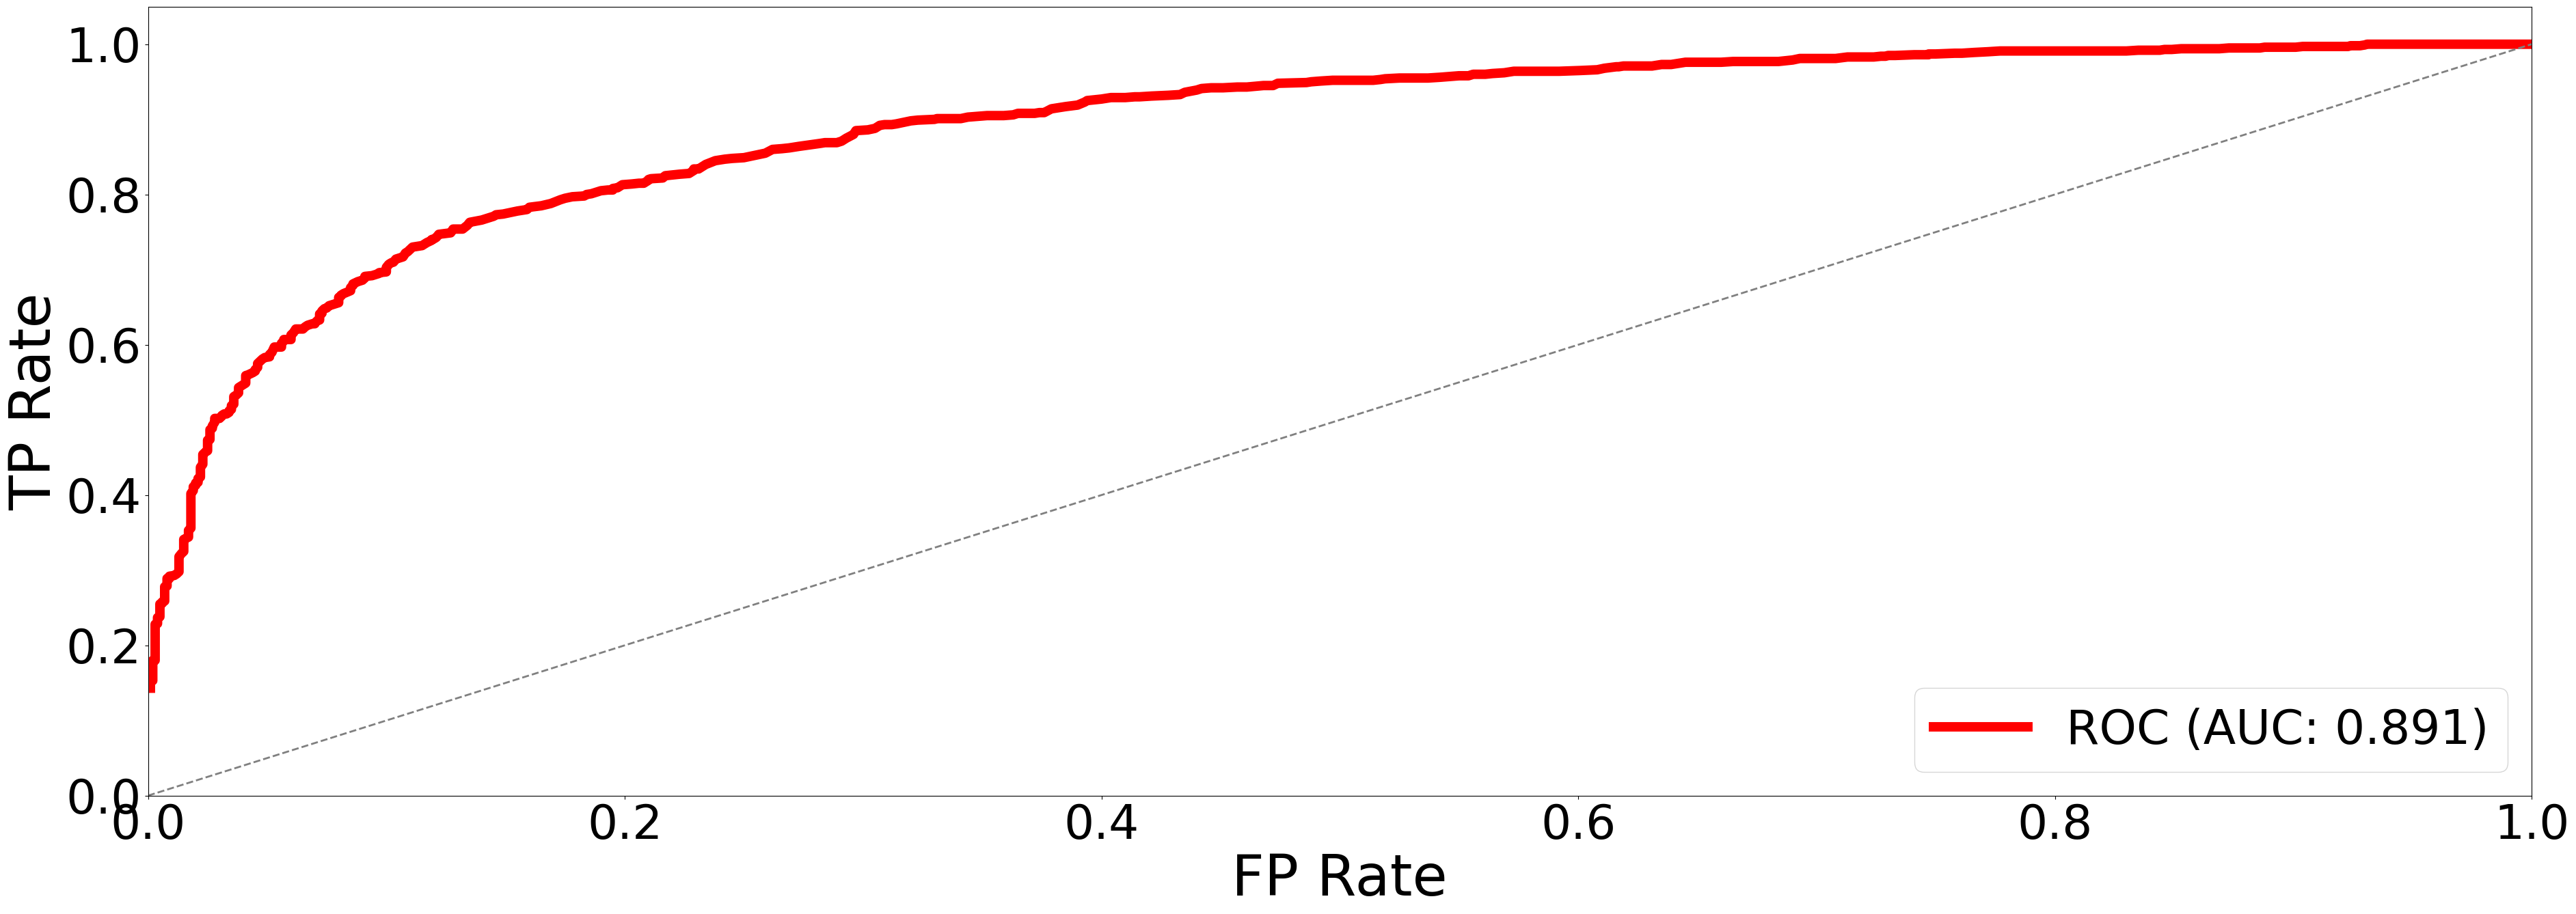

Method: KNN
Normal Dataset Used: alpha SNR-20 TS-2000
Size of Training Set: 2000
Test Set Used: alpha SNR-20 normal along with alpha_sub SNR-20 anomaly instances
Size of Test Set: 1000 (normal) 1000 (anomalous) 
Neighbors: 10
Avg f1 score: 0.8113298127700432
Max f1 score: 0.8113298127700432
Min f1 score: 0.8113298127700432
Avg acc score: 0.814
Max acc score: 0.814
Min acc score: 0.814
Avg AUC score: 0.890892
Max AUC score: 0.890892
Min AUC score: 0.890892
Avg Precision score: 0.8496659242761693
Max Precision score: 0.8496659242761693
Min Precision score: 0.8496659242761693
Avg Recall score: 0.763
Max Recall score: 0.763
Min Recall score: 0.763
Time: 17.08357460005209


In [34]:
Training_Amount = 2000

NormalTrain = program_N[0:Training_Amount]
NormalTest = program_N[2000:3000]
AnomalyTest = program_A[0:1000]

normalTrainInst = "alpha SNR-" + SNR + " TS-" + str(Training_Amount)
normalTestInst = "alpha SNR-" +SNR
anomalyInst = "alpha_sub SNR-" +SNR

name = normalTrainInst + " vs " + anomalyInst

path = folder + name + "/"

kFold = 1

neighbor = np.array([10])

f1Best, accBest, aucBest, precBest, recallBest = KNN_Exp.runExperiment(NormalTrain, NormalTest, AnomalyTest, normalTrainInst, 
                                                    normalTestInst, anomalyInst, name, path, neighbors = neighbor, numFold = kFold)

Beginning Tests...


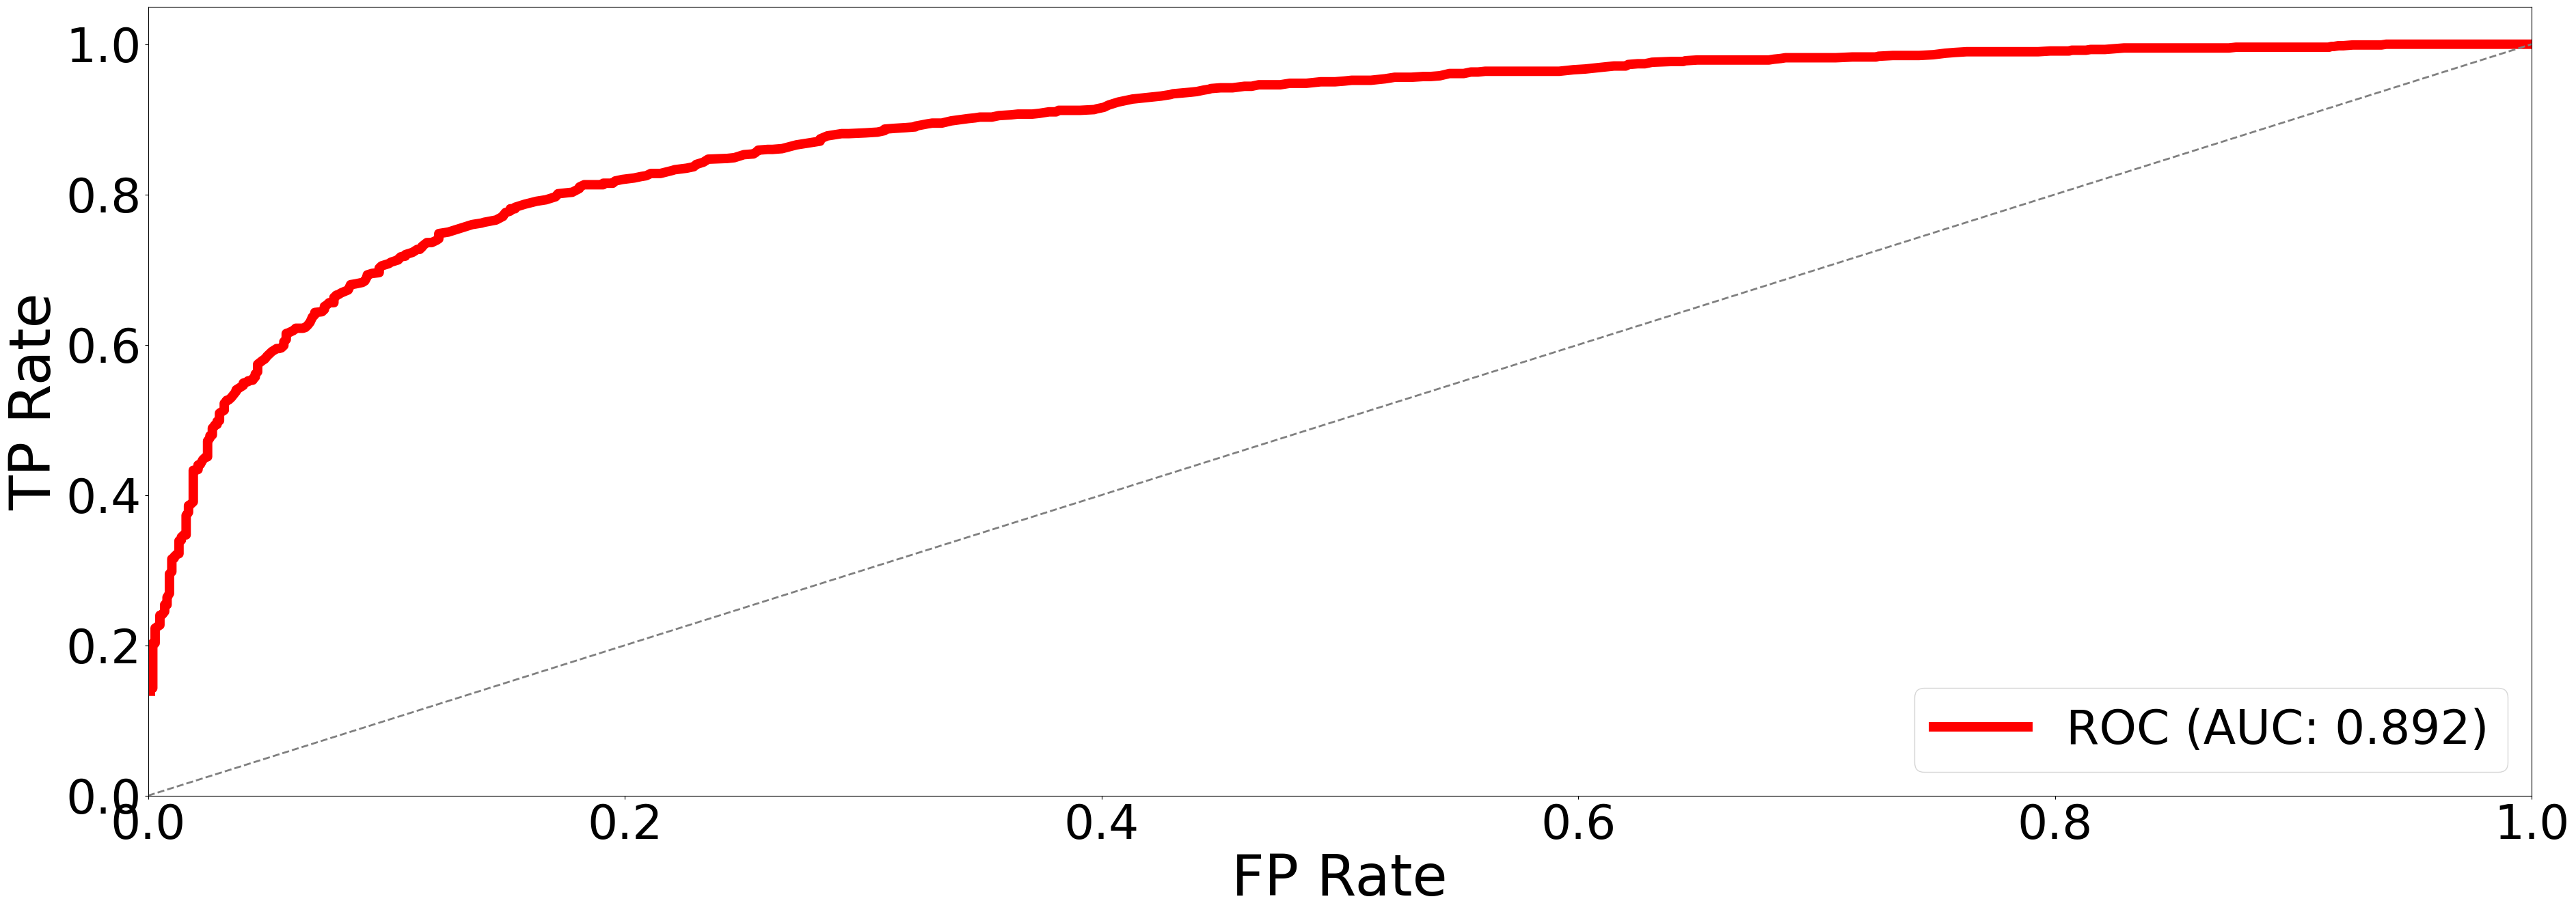

Method: KNN
Normal Dataset Used: alpha SNR-20 TS-1500
Size of Training Set: 1500
Test Set Used: alpha SNR-20 normal along with alpha_sub SNR-20 anomaly instances
Size of Test Set: 1000 (normal) 1000 (anomalous) 
Neighbors: 10
Avg f1 score: 0.814629258517034
Max f1 score: 0.814629258517034
Min f1 score: 0.814629258517034
Avg acc score: 0.815
Max acc score: 0.815
Min acc score: 0.815
Avg AUC score: 0.891819
Max AUC score: 0.891819
Min AUC score: 0.891819
Avg Precision score: 0.8162650602409639
Max Precision score: 0.8162650602409639
Min Precision score: 0.8162650602409639
Avg Recall score: 0.813
Max Recall score: 0.813
Min Recall score: 0.813
Time: 16.17526639997959


In [35]:
Training_Amount = 1500

NormalTrain = program_N[0:Training_Amount]
NormalTest = program_N[2000:3000]
AnomalyTest = program_A[0:1000]

normalTrainInst = "alpha SNR-" + SNR + " TS-" + str(Training_Amount)
normalTestInst = "alpha SNR-" +SNR
anomalyInst = "alpha_sub SNR-" +SNR

name = normalTrainInst + " vs " + anomalyInst

path = folder + name + "/"

kFold = 1

neighbor = np.array([10])

f1Best, accBest, aucBest, precBest, recallBest = KNN_Exp.runExperiment(NormalTrain, NormalTest, AnomalyTest, normalTrainInst, 
                                                    normalTestInst, anomalyInst, name, path, neighbors = neighbor, numFold = kFold)

Beginning Tests...


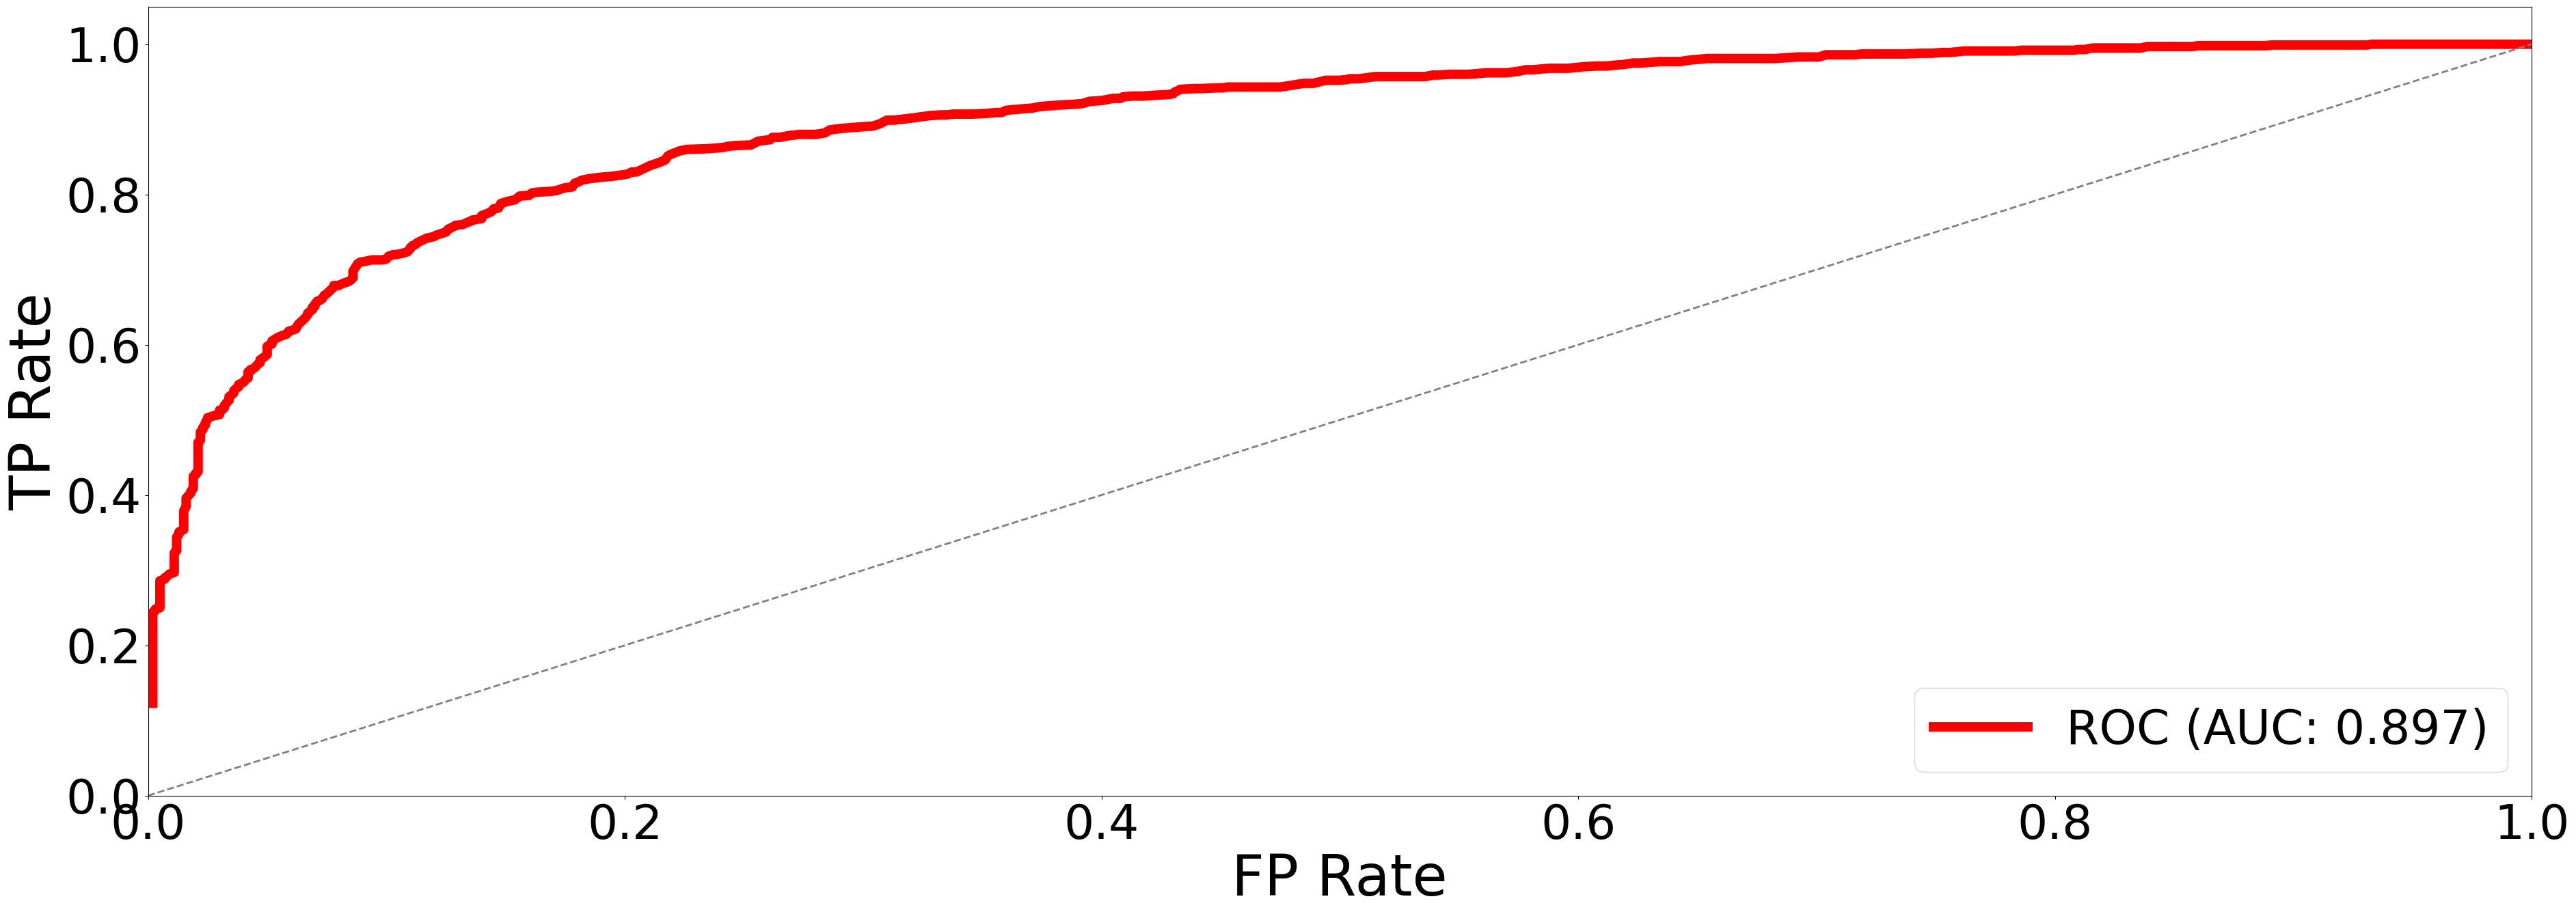

Method: KNN
Normal Dataset Used: alpha SNR-20 TS-1000
Size of Training Set: 1000
Test Set Used: alpha SNR-20 normal along with alpha_sub SNR-20 anomaly instances
Size of Test Set: 1000 (normal) 1000 (anomalous) 
Neighbors: 10
Avg f1 score: 0.8246035559827006
Max f1 score: 0.8246035559827006
Min f1 score: 0.8246035559827006
Avg acc score: 0.821
Max acc score: 0.821
Min acc score: 0.821
Avg AUC score: 0.8968905
Max AUC score: 0.8968905
Min AUC score: 0.8968905
Avg Precision score: 0.8364779874213837
Max Precision score: 0.8364779874213837
Min Precision score: 0.8364779874213837
Avg Recall score: 0.798
Max Recall score: 0.798
Min Recall score: 0.798
Time: 16.285678599961102


In [36]:
Training_Amount = 1000

NormalTrain = program_N[0:Training_Amount]
NormalTest = program_N[2000:3000]
AnomalyTest = program_A[0:1000]

normalTrainInst = "alpha SNR-" + SNR + " TS-" + str(Training_Amount)
normalTestInst = "alpha SNR-" +SNR
anomalyInst = "alpha_sub SNR-" +SNR

name = normalTrainInst + " vs " + anomalyInst

path = folder + name + "/"

kFold = 1

neighbor = np.array([10])

f1Best, accBest, aucBest, precBest, recallBest = KNN_Exp.runExperiment(NormalTrain, NormalTest, AnomalyTest, normalTrainInst, 
                                                    normalTestInst, anomalyInst, name, path, neighbors = neighbor, numFold = kFold)

Beginning Tests...


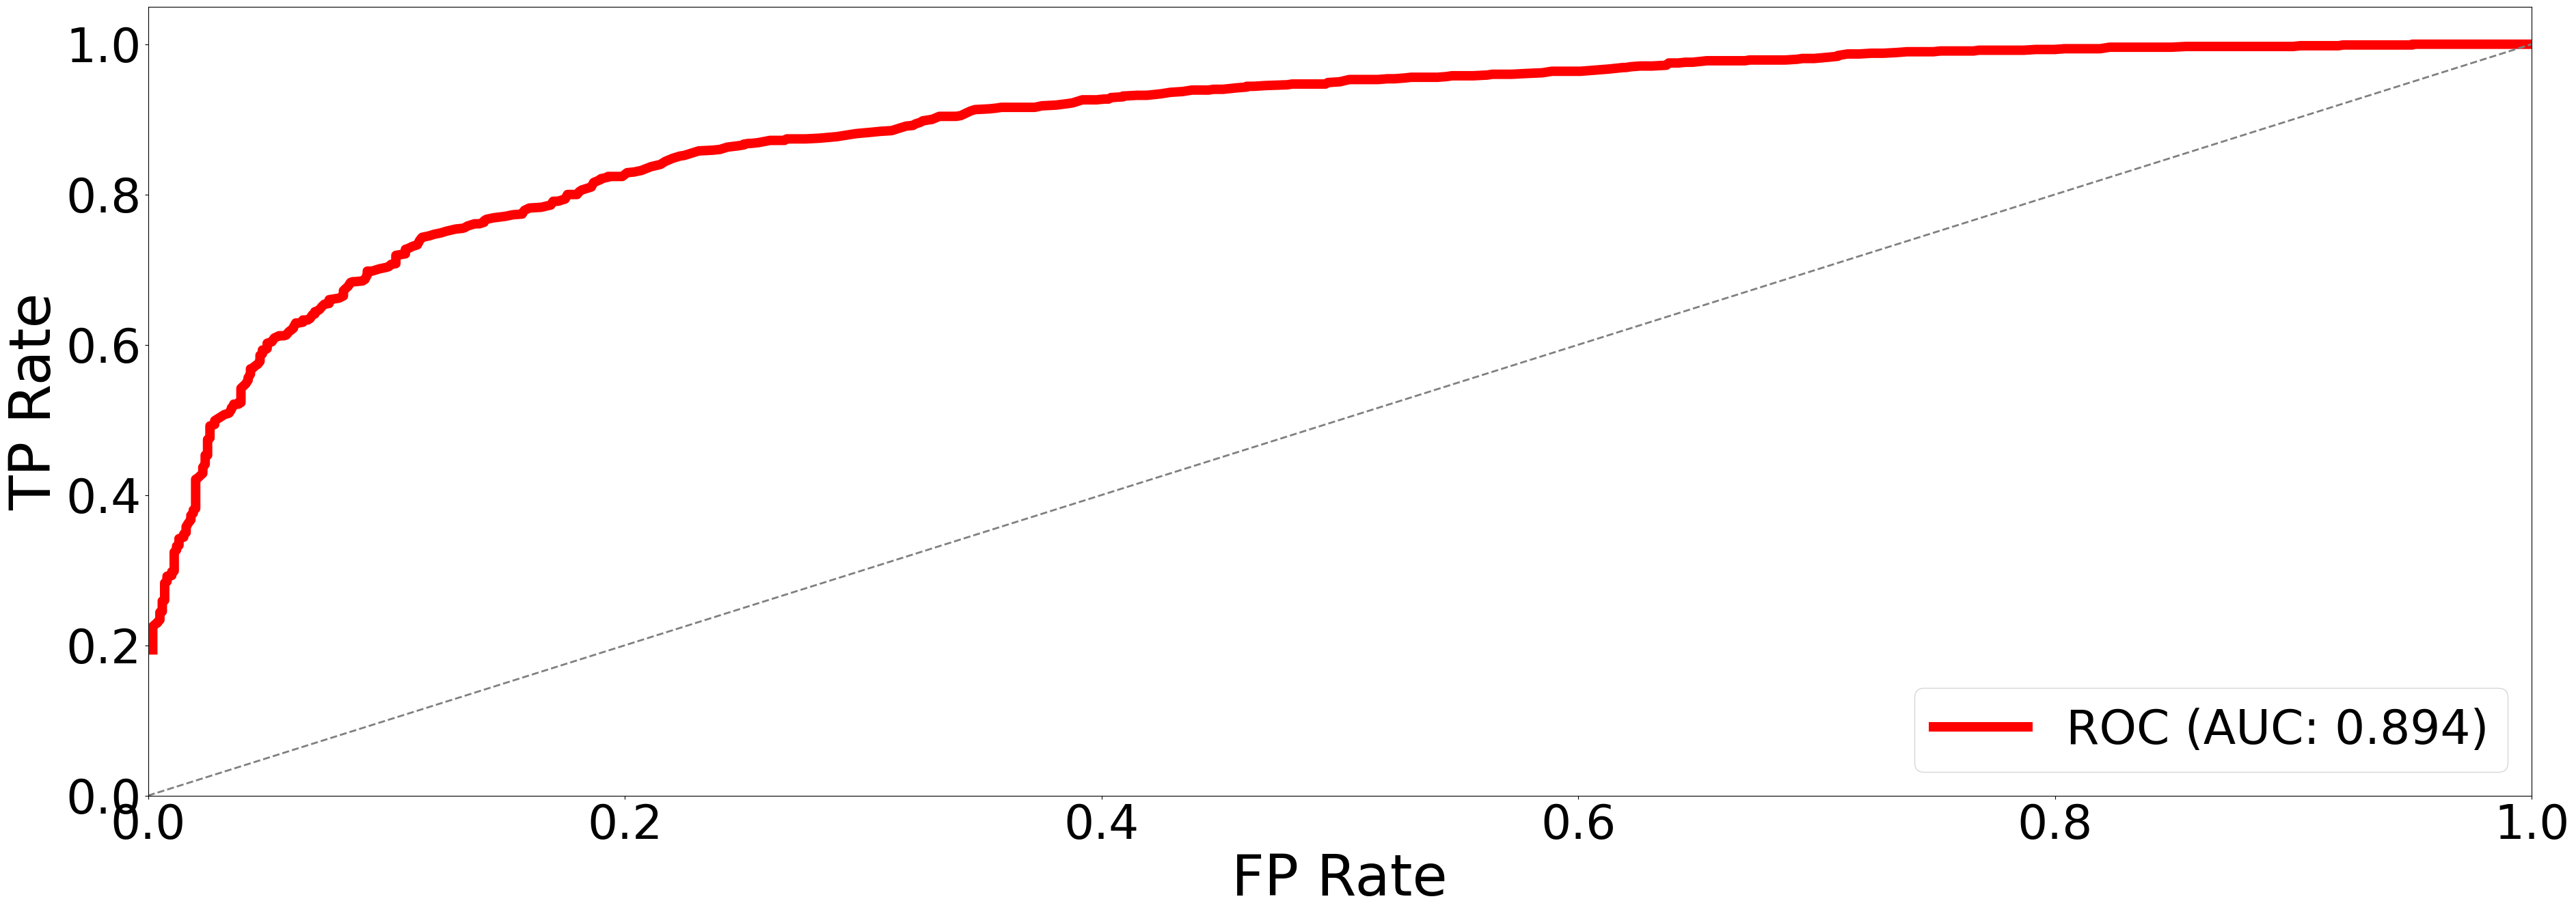

Method: KNN
Normal Dataset Used: alpha SNR-20 TS-500
Size of Training Set: 500
Test Set Used: alpha SNR-20 normal along with alpha_sub SNR-20 anomaly instances
Size of Test Set: 1000 (normal) 1000 (anomalous) 
Neighbors: 10
Avg f1 score: 0.8214456677836285
Max f1 score: 0.8214456677836285
Min f1 score: 0.8214456677836285
Avg acc score: 0.8155
Max acc score: 0.8155
Min acc score: 0.8155
Avg AUC score: 0.893643
Max AUC score: 0.893643
Min AUC score: 0.893643
Avg Precision score: 0.8120672601384767
Max Precision score: 0.8120672601384767
Min Precision score: 0.8120672601384767
Avg Recall score: 0.824
Max Recall score: 0.824
Min Recall score: 0.824
Time: 15.246756100095809


In [37]:
Training_Amount = 500

NormalTrain = program_N[0:Training_Amount]
NormalTest = program_N[2000:3000]
AnomalyTest = program_A[0:1000]

normalTrainInst = "alpha SNR-" + SNR + " TS-" + str(Training_Amount)
normalTestInst = "alpha SNR-" +SNR
anomalyInst = "alpha_sub SNR-" +SNR

name = normalTrainInst + " vs " + anomalyInst

path = folder + name + "/"

kFold = 1

neighbor = np.array([10])

f1Best, accBest, aucBest, precBest, recallBest = KNN_Exp.runExperiment(NormalTrain, NormalTest, AnomalyTest, normalTrainInst, 
                                                    normalTestInst, anomalyInst, name, path, neighbors = neighbor, numFold = kFold)

Beginning Tests...


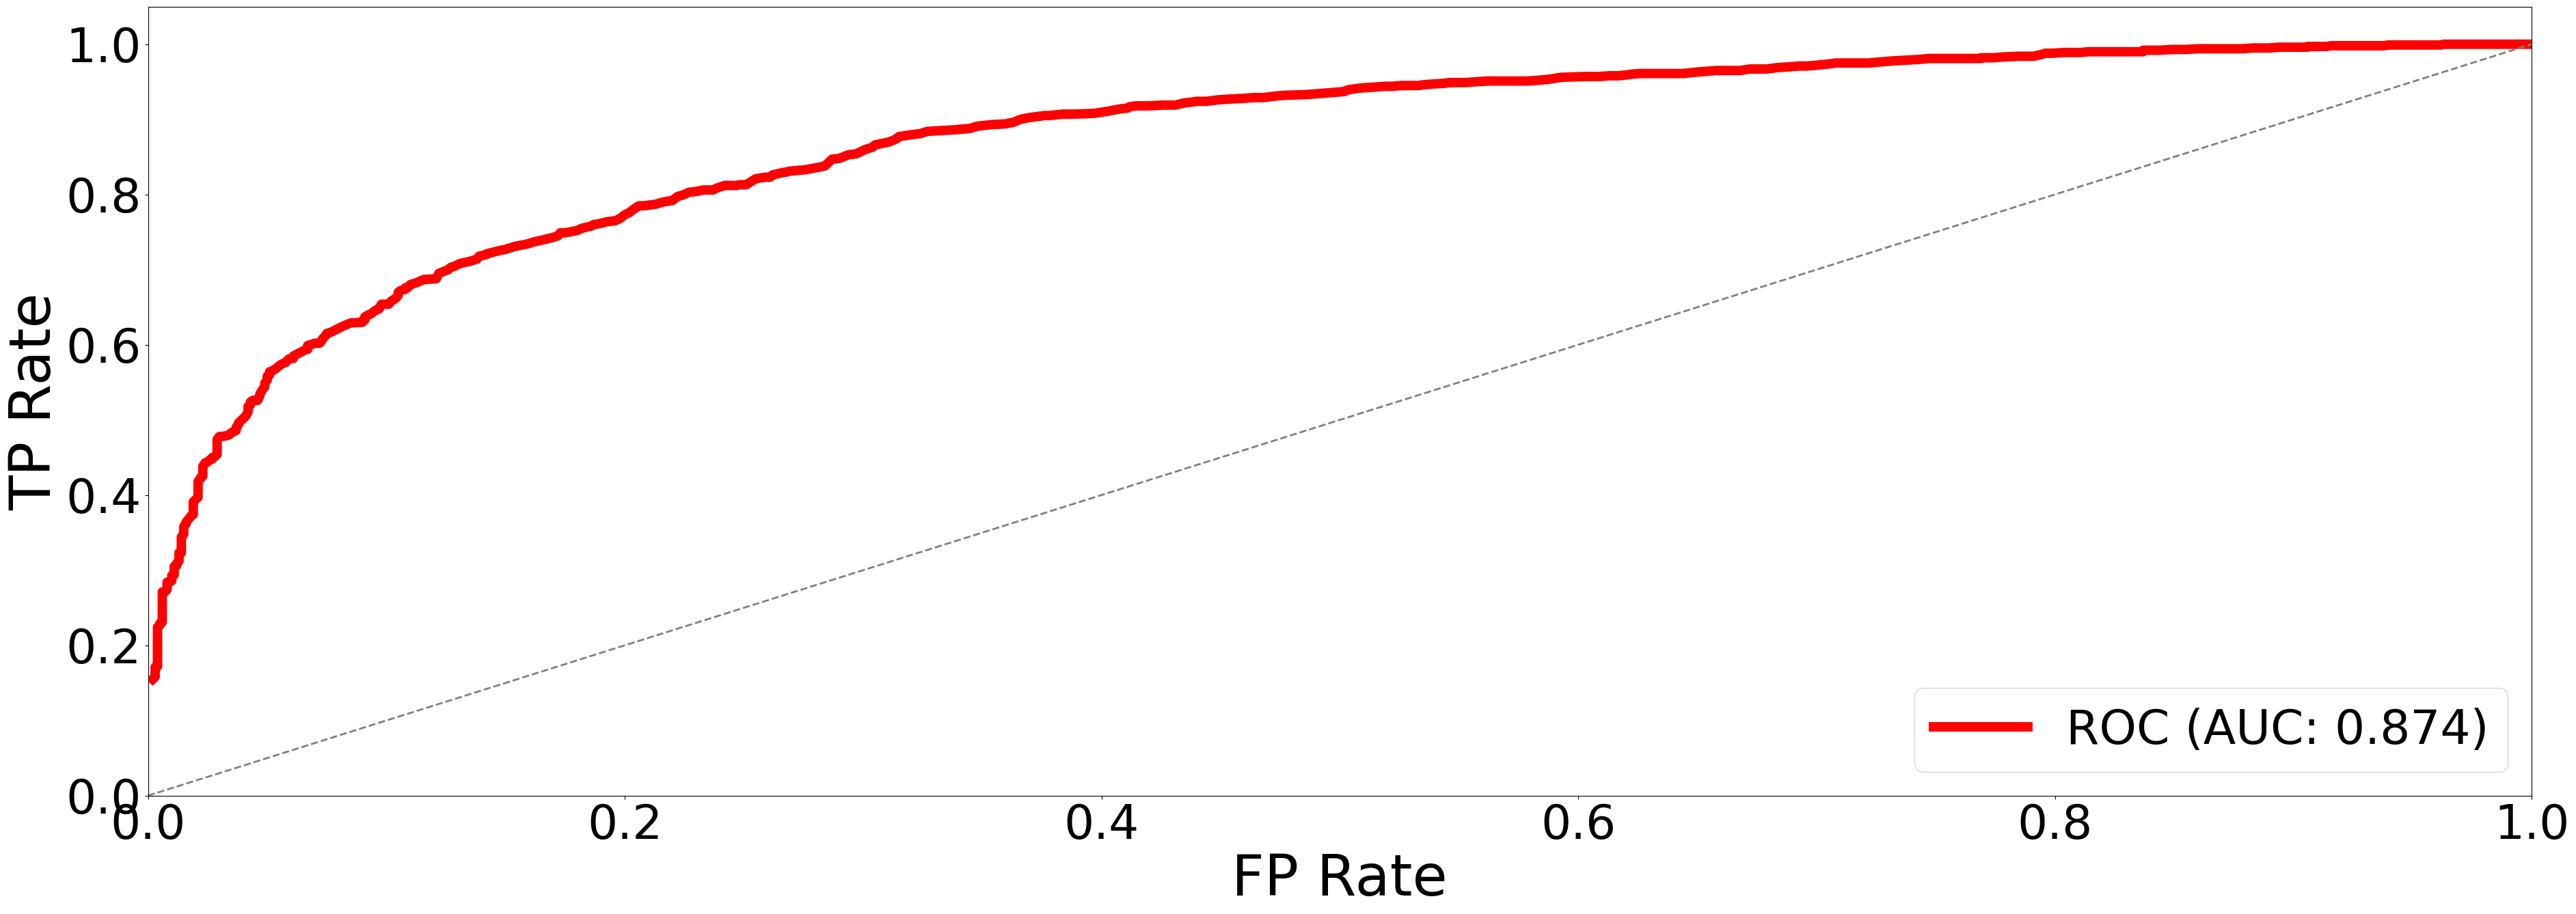

Method: KNN
Normal Dataset Used: alpha SNR-20 TS-100
Size of Training Set: 100
Test Set Used: alpha SNR-20 normal along with alpha_sub SNR-20 anomaly instances
Size of Test Set: 1000 (normal) 1000 (anomalous) 
Neighbors: 10
Avg f1 score: 0.8001824817518248
Max f1 score: 0.8001824817518248
Min f1 score: 0.8001824817518248
Avg acc score: 0.7895
Max acc score: 0.7895
Min acc score: 0.7895
Avg AUC score: 0.8740545
Max AUC score: 0.8740545
Min AUC score: 0.8740545
Avg Precision score: 0.8378063010501751
Max Precision score: 0.8378063010501751
Min Precision score: 0.8378063010501751
Avg Recall score: 0.785
Max Recall score: 0.785
Min Recall score: 0.785
Time: 16.6863717000233


In [38]:
Training_Amount = 100

NormalTrain = program_N[0:Training_Amount]
NormalTest = program_N[2000:3000]
AnomalyTest = program_A[0:1000]

normalTrainInst = "alpha SNR-" + SNR + " TS-" + str(Training_Amount)
normalTestInst = "alpha SNR-" +SNR
anomalyInst = "alpha_sub SNR-" +SNR

name = normalTrainInst + " vs " + anomalyInst

path = folder + name + "/"

kFold = 1

neighbor = np.array([10])

f1Best, accBest, aucBest, precBest, recallBest = KNN_Exp.runExperiment(NormalTrain, NormalTest, AnomalyTest, normalTrainInst, 
                                                    normalTestInst, anomalyInst, name, path, neighbors = neighbor, numFold = kFold)